In [7]:
from helpers.load import *
from helpers.select_scenario import select_scenario
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [8]:
scenario_folder_air = Path(os.path.abspath('')) / 'logs' / 'unified' / 'air'
scenario_folder_freshwater = Path(os.path.abspath('')) / 'logs' / 'unified' / 'freshwater'

In [9]:
def load_scenario_aggregate_df(scenario_folder, loader_function):
    agg_dfs = []
    for config_folder in sorted([folder for folder in scenario_folder.iterdir() if folder.is_dir()]):
        temp_df = loader_function(config_folder)
        temp_df['Config'] = config_folder.name
        agg_dfs.append(temp_df)
    
    return pd.concat(agg_dfs).reset_index(drop=True)

node_pos_freshwater = load_scenario_aggregate_df(scenario_folder_freshwater, load_node_pos_df)
power_state_freshwater = load_scenario_aggregate_df(scenario_folder_freshwater, load_power_state_df)

node_pos_air = load_scenario_aggregate_df(scenario_folder_air, load_node_pos_df)
power_state_air = load_scenario_aggregate_df(scenario_folder_air, load_power_state_df)

In [10]:
# Append the distance to 0,0,0
power_state_freshwater['Distance'] = np.sqrt(power_state_freshwater['NodeX']**2 + power_state_freshwater['NodeY']**2 + power_state_freshwater['NodeZ']**2)
power_state_air['Distance'] = np.sqrt(power_state_air['NodeX']**2 + power_state_air['NodeY']**2 + power_state_air['NodeZ']**2)

In [11]:
# For each config and distance, create a new table with the sum of the durations of power state RX
def calculate_power_state_duration(power_state_df):
    states_df = pd.DataFrame()
    states_df['Distance'] = power_state_df[power_state_df['NodeType'] != 'AP']['Distance'].unique()
    for state in ['RX', 'TX', 'IDLE', 'SLEEP', 'CCA_BUSY', 'SWITCHING']:
        state_duration = power_state_df[power_state_df['State'] == state].groupby(['Distance'])['Duration'].sum()
        states_df[state + "Time"] = states_df['Distance'].map(state_duration)
    return states_df

power_stats_freshwater = calculate_power_state_duration(power_state_freshwater)
power_stats_air = calculate_power_state_duration(power_state_air)

# Convert all RX, TX, IDLE, SLEEP, CCA_BUSY and SWITCHING times from ns to hours
power_stats_freshwater[['RXTime', 'TXTime', 'IDLETime', 'SLEEPTime', 'CCA_BUSYTime', 'SWITCHINGTime']] = power_stats_freshwater[['RXTime', 'TXTime', 'IDLETime', 'SLEEPTime', 'CCA_BUSYTime', 'SWITCHINGTime']] / 1e9 / 3600
power_stats_air[['RXTime', 'TXTime', 'IDLETime', 'SLEEPTime', 'CCA_BUSYTime', 'SWITCHINGTime']] = power_stats_air[['RXTime', 'TXTime', 'IDLETime', 'SLEEPTime', 'CCA_BUSYTime', 'SWITCHINGTime']] / 1e9 / 3600

# Multiply the time by the power consumption of each state
# Constants from https://www.nsnam.org/docs/release/3.23/doxygen/classns3_1_1_wifi_radio_energy_model.html
voltage = 3
power_stats_freshwater['RXPower'] = power_stats_freshwater['RXTime'] * voltage * 0.313
power_stats_freshwater['TXPower'] = power_stats_freshwater['TXTime'] * voltage * 0.38
power_stats_freshwater['IDLEPower'] = power_stats_freshwater['IDLETime'] * voltage * 0.273
power_stats_freshwater['SLEEPPower'] = power_stats_freshwater['SLEEPTime'] * voltage * 0.033
power_stats_freshwater['CCA_BUSYPower'] = power_stats_freshwater['CCA_BUSYTime'] * voltage * 0.273
power_stats_freshwater['SWITCHINGPower'] = power_stats_freshwater['SWITCHINGTime'] * voltage * 0.273

power_stats_air['RXPower'] = power_stats_air['RXTime'] * voltage * 0.313
power_stats_air['TXPower'] = power_stats_air['TXTime'] * voltage * 0.38
power_stats_air['IDLEPower'] = power_stats_air['IDLETime'] * voltage * 0.273
power_stats_air['SLEEPPower'] = power_stats_air['SLEEPTime'] * voltage * 0.033
power_stats_air['CCA_BUSYPower'] = power_stats_air['CCA_BUSYTime'] * voltage * 0.273
power_stats_air['SWITCHINGPower'] = power_stats_air['SWITCHINGTime'] * voltage * 0.273

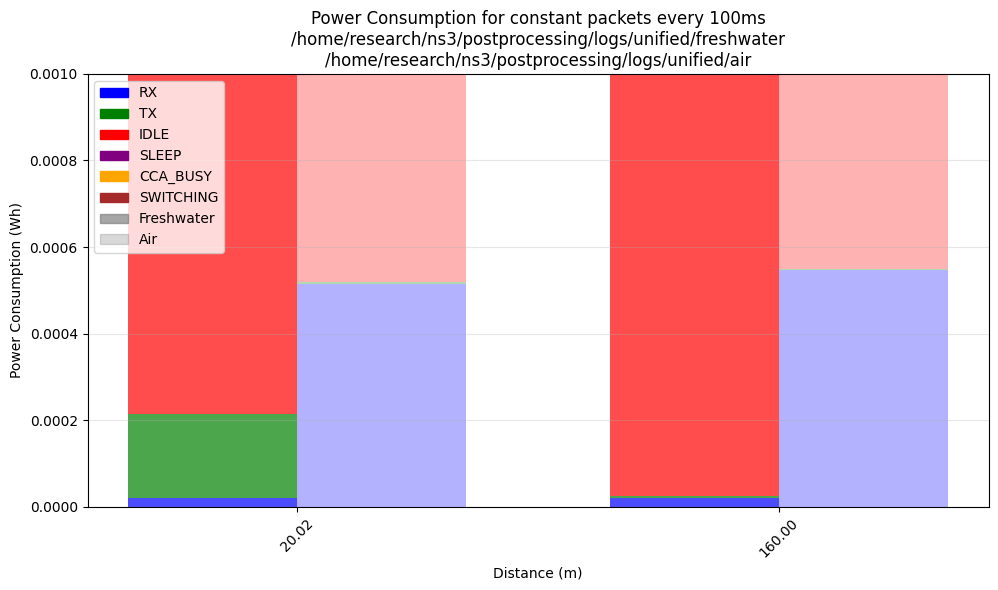

In [12]:
plt.figure(figsize=(10, 6))

# Use a stacked bar plot to show the power consumption of each state. Do one bar per distance. Have freshwater and air bars side by side
# Select a subset of distances for better visualization
common_distances = sorted(set(power_stats_freshwater['Distance']).intersection(set(power_stats_air['Distance'])))
plot_distances = common_distances[::20]  # Take every 20th distance for clarity

# Set up bar positions
bar_width = 0.35
x = np.arange(len(plot_distances))

# Power states and colors
power_states = ['RXPower', 'TXPower', 'IDLEPower', 'SLEEPPower', 'CCA_BUSYPower', 'SWITCHINGPower']
colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown']

# Plot stacked bars for freshwater
bottom_fw = np.zeros(len(plot_distances))
for state, color in zip(power_states, colors):
    fw_values = [power_stats_freshwater.loc[power_stats_freshwater['Distance'] == d, state].fillna(0).values[0] 
                if len(power_stats_freshwater.loc[power_stats_freshwater['Distance'] == d]) > 0 else 0 
                for d in plot_distances]
    
    plt.bar(x - bar_width/2, fw_values, bar_width, bottom=bottom_fw, 
            color=color, alpha=0.7)
    bottom_fw += fw_values

# Plot stacked bars for air
bottom_air = np.zeros(len(plot_distances))
for state, color in zip(power_states, colors):
    air_values = [power_stats_air.loc[power_stats_air['Distance'] == d, state].fillna(0).values[0] 
                 if len(power_stats_air.loc[power_stats_air['Distance'] == d]) > 0 else 0 
                 for d in plot_distances]
    
    plt.bar(x + bar_width/2, air_values, bar_width, bottom=bottom_air, 
            color=color, alpha=0.3)
    bottom_air += air_values

# Create custom legend
legend_elements = [plt.Rectangle((0,0), 1, 1, color=color, label=state.replace('Power', '')) 
                  for state, color in zip(power_states, colors)]
legend_elements.append(plt.Rectangle((0,0), 1, 1, color='gray', alpha=0.7, label='Freshwater'))
legend_elements.append(plt.Rectangle((0,0), 1, 1, color='gray', alpha=0.3, label='Air'))

plt.legend(handles=legend_elements, loc='upper left')
plt.xticks(x, [f"{d:.2f}" for d in plot_distances], rotation=45)
plt.xlabel('Distance (m)')
plt.ylabel('Power Consumption (Wh)')
plt.title(f'Power Consumption for constant packets every 100ms\n{scenario_folder_freshwater}\n{scenario_folder_air}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim(0, 0.0010)
plt.show()

